# Assignment Part A
student ID: 14210037

Spatial Graph Convolutional Network (SpaGCN) is a widely-used computational framework for analyzing Spatial Transcriptomics. It applies early fusion by integrating three modalities: gene expression, spatial coordinates, and histology images. This integration is achieved by constructing a weighted spatial graph that accounts for both physical distance and visual differences from histology images, followed by feature extraction using a Graph Neural Networks (GNNs).

reference: Hu, Jian, et al. “SpaGCN: Integrating Gene Expression, Spatial Location and Histology to Identify Spatial Domains and Spatially Variable Genes by Graph Convolutional Network.” Nature Methods, vol. 18, no. 11, 28 Oct. 2021, pp. 1342–1351, https://doi.org/10.1038/s41592-021-01255-8.

This study will apply SpaGCN to identify and cluster tissue domains (cortical layers) in the human dorsolateral prefrontal cortex (DLPFC). The model inputs include the gene expression matrix (filtered_feature_bc_matrix.h5), spatial data, and the high-resolution histology image (151676_full_image.tif).

The main objectives of this study are:
1. Clustering Evaluation: Evaluate the SpaGCN (K-means) clustering performance against the manually annotated cortical layer labels (provided ground-truth) on both average and per-label metrics.
2. Histology Effect Analysis: Investigate how the contribution of histology information affects the clustering results by tuning the histology contribution parameter from s = 1 to s=0 (no contribution), and s=10 (high contribution)

### library install


In [ ]:
pip install scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 38.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2

In [ ]:
pip install SpaGCN

  Using cached SpaGCN-1.2.7-py3-none-any.whl.metadata (2.5 kB)
  Using cached python_igraph-1.0.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached louvain-0.8.2.tar.gz (4.2 MB)
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of python-igraph to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 42.9 MB/s eta 0:00:00
  Created wheel for louvain: filename=louvain-0.8.2-cp312-cp312-linux_x86_64.whl size=971749 sha256=f23784e3f09f11392c81fee7edecc7a6d3a32175cf1fc33cce64c4d1e3f2a5ed
  Stored in directory: /root/.cache/pip/wheels/40/de/2b/bb7ed19d84727f9f299f20cd34c42bba9c8bef7d83d2255c86
Successfully built louvain


In [ ]:
import os,csv,re
import pandas as pd
import numpy as np
import scanpy as sc
import math
from scipy.sparse import issparse
import random, torch
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import SpaGCN as spg
import cv2

import random, torch
from sklearn import metrics

# Load the Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# import os

# def find_file(name, path):
#     for root, dirs, files in os.walk(path):
#         if name in files:
#             return os.path.join(root, name)
#     return None

# real_path = find_file('filtered_feature_bc_matrix.h5', '/content/drive/MyDrive')

# if real_path:
#     print("")
#     print(f"'{real_path}'")
# else:
#     print("No found")


In [ ]:
#Read in gene expression and spatial location
base_path = '/content/drive/MyDrive/Colab Notebooks/data/151676'
adata_spg = sc.read_visium(path = base_path,
               count_file='filtered_feature_bc_matrix.h5',
               load_images=True)
adata_spg.var_names_make_unique()
adata_spg.var['SYMBOL'] = adata_spg.var_names

# Ground-truth labels
histo_2 = pd.read_csv(base_path + '/151676_truth.txt', sep="\t").dropna()
histo_2.index = histo_2['Barcode']
adata_spg = adata_spg[adata_spg.obs_names.isin(histo_2['Barcode']),:]

# Spatial
spatial = pd.read_csv(base_path + '/spatial/tissue_positions_list.csv', sep=",", header=None, na_filter=False, index_col=0)
spatial=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data/151676/spatial/tissue_positions_list.csv",sep=",",header=None,na_filter=False,index_col=0)

## Align spatial metadata with AnnData object
adata_spg.obs["x1"] = spatial[1]
adata_spg.obs["x2"] = spatial[2]
adata_spg.obs["x3"] = spatial[3]
adata_spg.obs["x4"] = spatial[4]
adata_spg.obs["x5"] = spatial[5]

## SpaGCN computatioon needs pixel
adata_spg.obs["x_array"] = adata_spg.obs["x2"]
adata_spg.obs["y_array"] = adata_spg.obs["x3"]
adata_spg.obs["x_pixel"] = adata_spg.obs["x4"]
adata_spg.obs["y_pixel"] = adata_spg.obs["x5"]

## Filter out spots outside the tissue background
adata_spg = adata_spg[adata_spg.obs["x1"] == 1]
## Normalize gene names format (Uppercase)
adata_spg.var_names = [i.upper() for i in list(adata_spg.var_names)]
adata_spg.var["genename"] = adata_spg.var.index.astype("str")

# Image
img = cv2.imread(base_path + '/spatial/151676_full_image.tif')

# Integrate gene expression and histology into a Graph

In [ ]:
#Set coordinates
x_array=adata_spg.obs["x_array"].tolist()
y_array=adata_spg.obs["y_array"].tolist()
x_pixel=adata_spg.obs["x_pixel"].tolist()
y_pixel=adata_spg.obs["y_pixel"].tolist()

#Test coordinates on the image
img_new=img.copy()
for i in range(len(x_pixel)):
    x=x_pixel[i]
    y=y_pixel[i]
    img_new[int(x-20):int(x+20), int(y-20):int(y+20),:]=0

cv2.imwrite('ic_map.jpg', img_new)

True

In [ ]:
spg.prefilter_genes(adata_spg,min_cells=3)  # Filter low-quality genes
spg.prefilter_specialgenes(adata_spg)    # Filter special genes

sc.pp.normalize_per_cell(adata_spg)     # Normalize and take log for UMI
sc.pp.log1p(adata_spg) # gene expression distribution usually Skewness

In [ ]:
# from Sparse Matrix to Dense Matrix
import scipy.sparse
if scipy.sparse.issparse(adata_spg.X):
    adata_spg.X = adata_spg.X.toarray()

In [ ]:
# # how many cluster in ground-ture labels
# unique_labels = histo_2['Annotations'].dropna().unique()
# print(unique_labels)
# print("n_clusters = ", len(unique_labels))


['Layer_3' 'Layer_1' 'WM' 'Layer_6' 'Layer_5' 'Layer_2' 'Layer_4']
n_clusters =  7


In [ ]:
# histo_2.columns.tolist()

['Barcode', 'Annotations']

# Run SpaGCN
s=0, s=1 and s=10

In [ ]:
import copy
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import classification_report, confusion_matrix


# Save a clean snapshot of the preprocessed matrix ONCE before any runs
X_clean = adata_spg.X.copy()


def run_spagcn(s_val, b=49, n_clusters=7):
    # Restore clean data each run to avoid in-place corruption
    adata_spg.X = X_clean.copy()

    adj = spg.calculate_adj_matrix(
        x=x_pixel, y=y_pixel,
        x_pixel=x_pixel, y_pixel=y_pixel,
        image=img, beta=b, alpha=s_val, histology=True
    )

    # Set hyper-parameters
    p = 0.5
    l = spg.search_l(p, adj, start=0.01, end=1000, tol=0.01, max_run=100)

    # Run SpaGCN
    clf = spg.SpaGCN()
    clf.set_l(l)

    # Set seed
    random.seed(42); torch.manual_seed(123); np.random.seed(33)

    # Run
    clf.train(adata_spg, adj, init_spa=True, init="kmeans",
              n_clusters=n_clusters, tol=5e-3, lr=0.05, max_epochs=200)
    y_pred, prob = clf.predict()

    adata_spg.obs[f"pred_s{s_val}"] = y_pred
    adata_spg.obs[f"pred_s{s_val}"] = adata_spg.obs[f"pred_s{s_val}"].astype('category')

    # shape="hexagon" for Visium data, "square" for ST data.
    adj_2d = spg.calculate_adj_matrix(x=x_array, y=y_array, histology=False)
    refined = spg.refine(sample_id=adata_spg.obs.index.tolist(),
                         pred=adata_spg.obs[f"pred_s{s_val}"].tolist(),
                         dis=adj_2d, shape="hexagon")
    adata_spg.obs[f"SpaGCN_s{s_val}"] = refined
    adata_spg.obs[f"SpaGCN_s{s_val}"] = adata_spg.obs[f"SpaGCN_s{s_val}"].astype('category')

    # Spatial plot with ground truth side by side
    adata_spg.obs['ground_truth'] = histo_2['Annotations'] # Assign Ground-Truth
    sc.pl.spatial(adata_spg, color=['ground_truth', f"SpaGCN_s{s_val}"], size=1.5,
                  title=['Ground truth', f'SpaGCN s={s_val}'])

    return refined

Calculateing adj matrix using histology image...
Var of c0,c1,c2 =  29.477509465304824 174.8015556779522 60.95093839727311
Var of x,y,z =  5080995.703721643 4365111.426668278 0.0
Run 1: l [0.01, 1000], p [0.0, 302.62073]
Run 2: l [0.01, 500.005], p [0.0, 83.80005]
Run 3: l [0.01, 250.0075], p [0.0, 21.370054]
Run 4: l [0.01, 125.00874999999999], p [0.0, 4.762879]
Run 5: l [0.01, 62.509375], p [0.0, 0.5128654]
Run 6: l [31.2596875, 62.509375], p [0.00034153461, 0.5128654]
Run 7: l [46.884531249999995, 62.509375], p [0.076499104, 0.5128654]
Run 8: l [54.69695312499999, 62.509375], p [0.24173272, 0.5128654]
Run 9: l [58.6031640625, 62.509375], p [0.36513805, 0.5128654]
Run 10: l [60.556269531249995, 62.509375], p [0.43615878, 0.5128654]
Run 11: l [61.532822265625, 62.509375], p [0.47382724, 0.5128654]
recommended l =  62.021098632812496
Initializing cluster centers with kmeans, n_clusters known
Epoch  0
Epoch  10
Epoch  20
Epoch  30
Epoch  40
delta_label  0.0034975226 < tol  0.005
Reach t

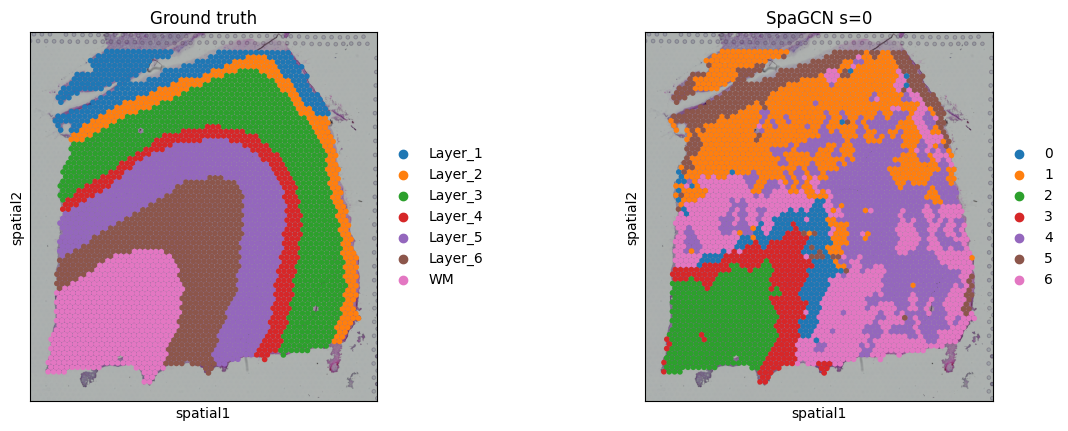

Calculateing adj matrix using histology image...
Var of c0,c1,c2 =  29.477509465304824 174.8015556779522 60.95093839727311
Var of x,y,z =  5080995.703721643 4365111.426668278 5080995.703721643
Run 1: l [0.01, 1000], p [0.0, 161.74712]
Run 2: l [0.01, 500.005], p [0.0, 30.984821]
Run 3: l [0.01, 250.0075], p [0.0, 4.849618]
Run 4: l [0.01, 125.00874999999999], p [0.0, 0.61408424]
Run 5: l [62.509375, 125.00874999999999], p [0.03502941, 0.61408424]
Run 6: l [93.7590625, 125.00874999999999], p [0.22746468, 0.61408424]
Run 7: l [109.38390625, 125.00874999999999], p [0.3941188, 0.61408424]
recommended l =  117.196328125
Initializing cluster centers with kmeans, n_clusters known
Epoch  0
Epoch  10
Epoch  20
Epoch  30
Epoch  40
delta_label  0.0046633636 < tol  0.005
Reach tolerance threshold. Stopping training.
Total epoch: 49
Calculateing adj matrix using xy only...


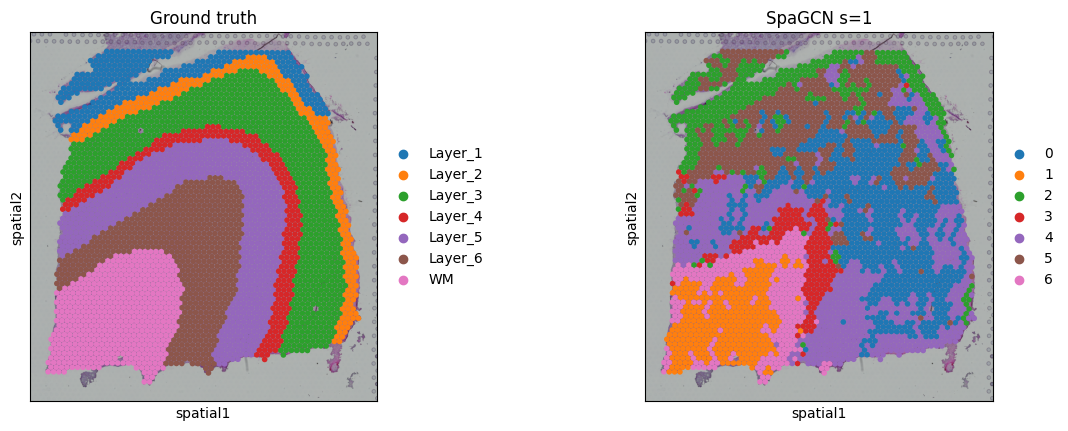

Calculateing adj matrix using histology image...
Var of c0,c1,c2 =  29.477509465304824 174.8015556779522 60.95093839727311
Var of x,y,z =  5080995.703721643 4365111.426668278 508099570.37216437
Run 1: l [0.01, 1000], p [0.0, 20.071339]
Run 2: l [0.01, 500.005], p [0.0, 3.4055986]
recommended l =  250.0075
Initializing cluster centers with kmeans, n_clusters known
Epoch  0
Epoch  10
Epoch  20
Epoch  30
Epoch  40
Epoch  50
Epoch  60
Epoch  70
Epoch  80
Epoch  90
Epoch  100
Epoch  110
Epoch  120
delta_label  0.0043719034 < tol  0.005
Reach tolerance threshold. Stopping training.
Total epoch: 121
Calculateing adj matrix using xy only...


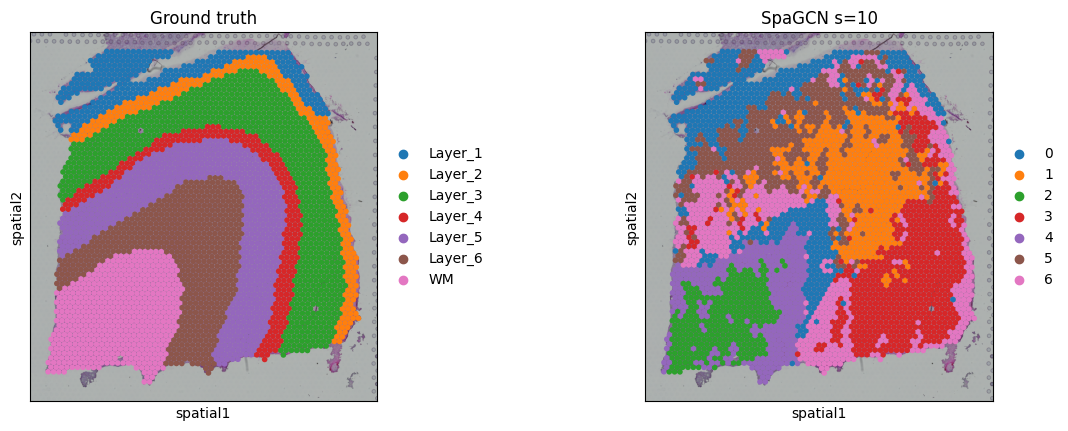

In [ ]:
trained_refined_data = {}
for s in [0, 1, 10]:
    trained_refined_data[s] = run_spagcn(s)


#### From visualization
Regardless of how the value of *s* varies, SpaGCN consistently identifies Layer 1 (blue) at the brain periphery, White Matter (WM, pink region) and Layer 6 (brown) at the bottom. This stability might arise because the outermost and innermost layers inherently possess highly pronounced distinctiveness in both their transcriptomic profiles and histological morphologies.

When *s=1*, the model achieves an optimal balance between the modalities. It successfully captures the stratification trend of the intermediate cortical layers (Layers 2–5), which present as continuous band-like layers in an arching shape. This demonstrates that introducing a moderate amount of histological features serves as a spatial smoothing constraint, thereby helping to maintain biological spatial continuity.

With *s=0* (omitting image information entirely), the clustering output appears somewhat noisy and fragmented. In the absence of histological morphological assistance, relying solely on gene expression makes the model susceptible to local sequencing noise, preventing the intermediate cortical layers from forming continuous bands.

Conversely, when *s=10* (relying excessively on image information), the clustering results exhibit over-clustered, blob-like artifacts. This is particularly evident in the intermediate region, where what should be parallel, arching strata have fused into massive aggregated blobs. This occurs because subtle local variations in texture, cell density, or staining within the high-resolution image overwhelm the transcriptomic stratification signals, leading the model to misclassify different cortical layers into the same broad morphological cluster.

#### From Epochs
- *s=0* : 46 epochs
- *s=1* : 49 epochs
- *s=10* : 121 epochs

This indicates that at *s=10*, the excessive weighting of image features creates a profound feature mismatch between its internal feature distribution and pure spatial coordinates. Consequently, this mismatch exacerbates the difficulty of graph optimisation within the GCN, hampering convergence and ultimately leading to the sub-optimal outcome of blurred layer boundaries and amorphous blob-like clusters.

# Compare with Pathologist's annotations (ground-truth labels) using various metrics

In [ ]:
def run_hungarian_matching(s_val, pred_refined):
    true_labels = histo_2['Annotations'].values
    pred_int    = np.array(pred_refined, dtype=int)
    true_classes = sorted(histo_2['Annotations'].unique())
    pred_classes = sorted(np.unique(pred_int))

    ## build cost matrix (rows=true layers, cols=predicted clusters)
    cost = np.zeros((len(true_classes), len(pred_classes)), dtype=int)
    for i, t in enumerate(true_classes):
        for j, p_cls in enumerate(pred_classes):
            cost[i, j] = np.sum((true_labels == t) & (pred_int == p_cls))

    ## Hungarian algorithm — maximise overlap → minimise negative overlap
    row_ind, col_ind = linear_sum_assignment(-cost)
    ## build mapping dict  cluster_id → layer_name
    cluster_to_layer = {pred_classes[col_ind[i]]: true_classes[row_ind[i]]
                        for i in range(len(row_ind))}
    ## remap predicted labels
    pred_mapped = np.array([cluster_to_layer[p] for p in pred_int])

    # Average metrics
    fmi = metrics.fowlkes_mallows_score(true_labels, pred_mapped)
    ari = metrics.adjusted_rand_score(true_labels, pred_mapped)
    ami = metrics.adjusted_mutual_info_score(true_labels, pred_mapped)
    print(f"\ns={s_val} → FMI={fmi:.4f} | ARI={ari:.4f} | AMI={ami:.4f}")
    # Per-label metrics
    print("\nPer-label classification report:")
    print(classification_report(true_labels, pred_mapped, target_names=true_classes))

    # Confusion matrix
    cm = confusion_matrix(true_labels, pred_mapped, labels=true_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=true_classes, yticklabels=true_classes, cmap='Blues')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title(f'Confusion matrix — s={s_val}')
    plt.tight_layout(); plt.show()

    return {'fmi': fmi, 'ari': ari, 'ami': ami,
            'pred_mapped': pred_mapped, 'cluster_map': cluster_to_layer}



s=0 → FMI=0.3648 | ARI=0.2293 | AMI=0.3838

Per-label classification report:
              precision    recall  f1-score   support

     Layer_1       0.71      0.66      0.68       289
     Layer_2       0.10      0.30      0.15       254
     Layer_3       0.50      0.49      0.49       836
     Layer_4       0.00      0.00      0.00       254
     Layer_5       0.39      0.47      0.43       649
     Layer_6       0.92      0.26      0.41       616
          WM       0.99      0.72      0.84       533

    accuracy                           0.45      3431
   macro avg       0.52      0.42      0.43      3431
weighted avg       0.58      0.45      0.47      3431



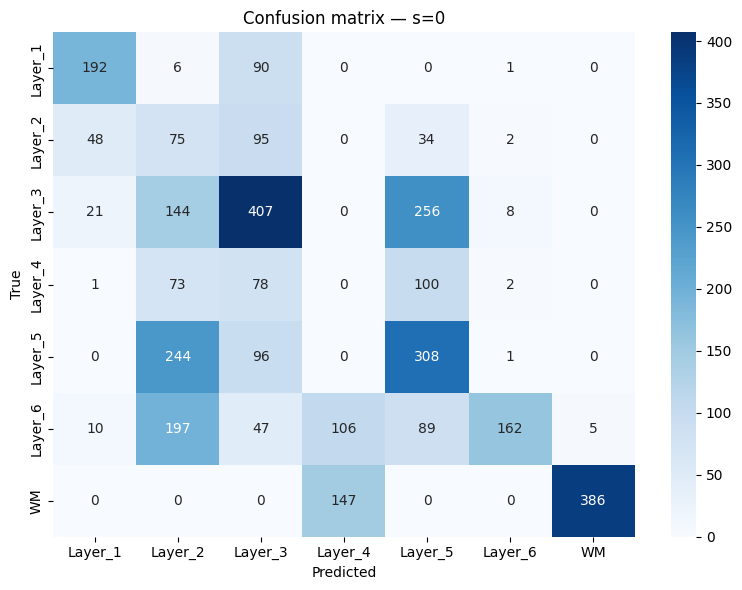


s=1 → FMI=0.3457 | ARI=0.2105 | AMI=0.3677

Per-label classification report:
              precision    recall  f1-score   support

     Layer_1       0.56      0.77      0.65       289
     Layer_2       0.10      0.30      0.15       254
     Layer_3       0.52      0.39      0.45       836
     Layer_4       0.00      0.00      0.00       254
     Layer_5       0.38      0.47      0.42       649
     Layer_6       0.91      0.28      0.43       616
          WM       0.98      0.62      0.76       533

    accuracy                           0.42      3431
   macro avg       0.49      0.40      0.41      3431
weighted avg       0.57      0.42      0.45      3431



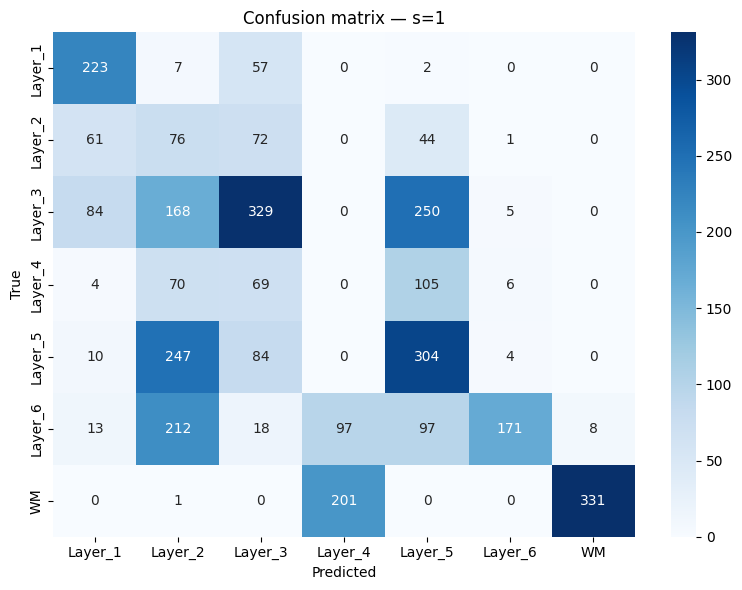


s=10 → FMI=0.3425 | ARI=0.2171 | AMI=0.3564

Per-label classification report:
              precision    recall  f1-score   support

     Layer_1       0.43      0.82      0.56       289
     Layer_2       0.20      0.44      0.27       254
     Layer_3       0.55      0.35      0.43       836
     Layer_4       0.15      0.37      0.21       254
     Layer_5       0.51      0.40      0.45       649
     Layer_6       0.30      0.17      0.22       616
          WM       1.00      0.56      0.71       533

    accuracy                           0.41      3431
   macro avg       0.45      0.44      0.41      3431
weighted avg       0.50      0.41      0.42      3431



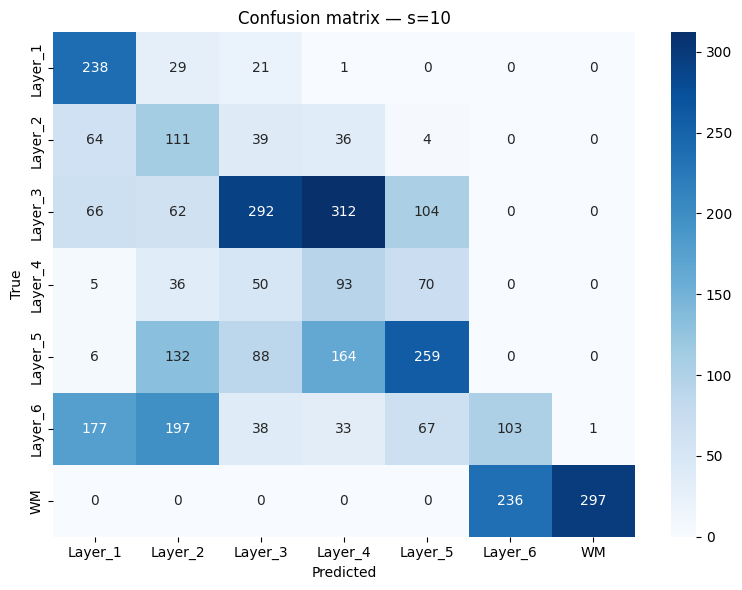

In [ ]:
evaluation_results = {}
for s in [0, 1, 10]:
    evaluation_results[s] = run_hungarian_matching(s, trained_refined_data[s])


- Fowlkes-Mallows Index (FMI)

This metric evaluates the geometric mean of precision and recall for spot pairs. It measures the probability that if a pair of spots belongs to the same true cortical layer, SpaGCN correctly assigns them to the same cluster.

The baseline without histology *s=0* yields the highest pair-wise consistency at 0.3648 (36.5% probability). Introducing balanced histological features *s=1* slightly drops this to 0.3457 (34.6%), and heavily weighting histology *s=10* reduces it further to 0.3425 (34.3%). This downward trend suggests that intense image features can over-segment or misalign local transcriptomic spot pairs.

- Adjusted Rand Index (ARI)

The ARI measures the global similarity between the true layer annotations and predicted clusters while adjusting for random chance

Across all configurations, the scores remain relatively low *s=0*: 0.2293, *s=1*: 0.2105, *s=10*: 0.2171. This demonstrates that a substantial portion of the tissue suffered from boundary confusion or layer misclassification. Interestingly, while *s=1* has the lowest global ARI, the transition to *s=10* brings a marginal rebound to 0.2171, driven by the model successfully isolating previously missed structural layers.

- Adjusted Mutual Information (AMI)

Based on Information Theory, AMI quantifies the amount of shared information between the ground-truth annotations and predicted clusters, adjusted for chance.

The shared structural information steadily declines as histology weight increases, dropping from 0.3838 *s=0* to 0.3677 *s=1*, and reaching its lowest at 0.3564 *s=10*. This confirms that relying excessively on morphological features introduces independent visual noise that diverges from the underlying transcriptomic architecture.



### Per-Label Classification

A granular inspection of the per-label classification reports above reveals crucial biological trade-offs and highlights how the histology parameter *s* re-shapes the model's clustering behavior:

1. The Layer 1 : High Precision at *s=0* vs High Recall at *s=10*

- At \(s=0\) (pure transcriptomics), the model is highly conservative; it only labels spots as Layer 1 if their gene expression profiles are distinctively clean, leading to high Precision (fewer false positives).

- At \(s=10\) (heavy histology), the model's graph is dominated by the distinct visual appearance of the tissue edge (the blank space boundary). Consequently, the model expands its search radius and aggressively classifies almost the entire biological edge into the Layer 1 cluster. This captures nearly all true Layer 1 spots, yielding a very high Recall, but inevitably sweeps in adjacent Layer 2 spots, causing Precision to drop to 0.43.

2. Layers 2, 3, 4, and 5

- Across Layers 2, 3, 4, and 5, \(s=10\) consistently delivers the highest Precision (0.20, 0.55, 0.15, and 0.51 respectively) compared to \(s=0\) and \(s=1\).

- Most notably, Layer 4 is completely missed under \(s=0\) and \(s=1\), returning an F1-score of 0.00. Only when \(s=10\) is applied does the model successfully distinguish Layer 4, achieving an F1-score of 0.21. This demonstrates that transcriptomic signals alone are insufficient to isolate this layer, and strong morphological constraints are mandatory to uncover its boundaries.

- While Layer 3 Precision improves at \(s=10\), its F1-score (0.43) is slightly lower than that of \(s=0\) (0.49) and \(s=1\) (0.45). This indicates that while the spots classified as Layer 3 at \(s=10\) are highly accurate (High Precision), a considerable number of true Layer 3 spots are partitioned into other clusters due to over-segmentation (Lower Recall of 0.35).

3. Layer 6 Optima and Misclassification Patterns

When histology is under-weighted (\(s=0\)), Layer 6 suffers from a low recall of 0.26, where a significant portion of its spots are misclassified into Layer 3 due to overlapping transcriptomic signatures. Introducing a balanced amount of histology (\(s=1\)) resolves some of this confusion.

However, over-weighting histology (\(s=10\)) catastrophically degrades Layer 6 performance (F1 drops to 0.22, Precision to 0.30) as it gets visually entangled with neighboring morphological clusters.

4. White Matter (WM)

White Matter performs exceptionally well under \(s=0\), securing the highest F1-score of 0.84 and a strong recall of 0.72.

This indicates that \(s=0\) is highly accurate at predicting structural extremes and distinct boundaries. Because White Matter (the innermost core) and Layer 1 (the outermost edge) possess starkly contrasting gene expression profiles compared to the intermediate grey matter, a purely transcriptomic approach excels at anchoring these two structural poles. When histology is introduced (\(s=1\) and \(s=10\)), the visual transitional gradients between Layer 6 and WM cause the model to blur this distinct boundary, thereby reducing WM recall to 0.56 at \(s=10\).

# Conclusion

In conclusion, this study demonstrates that the choice of the histology contribution parameter (\(s\)) in SpaGCN does not yield a single "optimal" configuration, but rather dictates a profound trade-off between global statistical alignment, spatial continuity, and local layer resolution.

- Qualitatively, visual inspection of the spatial clustering maps suggests that \(s=1\) provides the most anatomically faithful representation, as it successfully preserves the continuous, arching characteristics inherent to the cortical layers without excessive fragmentation.
- However, quantitative evaluation tells a different story;

  1.  the global clustering metrics indicate that the purely transcriptomic approach (\(s=0\)) achieves the highest statistical accuracy, peaking at an FMI of 0.3648. A granular, per-label investigation resolves this discrepancy by revealing that \(s=0\)'s superiority is strictly confined to highly distinct structural extremes, where gene expression profiles are inherently non-overlapping.
  2. Conversely, the heavy histology setting (\(s=10\)) proves far superior at delineating the intermediate grey matter (Layers 2–5), establishing itself as the exclusive parameter capable of recovering the elusive Layer 4, albeit at the cost of inducing severe over-clustering and blob-like artifacts elsewhere.

Ultimately, there is no universally superior parameter combination.

 The optimal configuration is highly context-dependent and must be aligned with specific downstream clinical or biological objectives.

  If the clinical focus is to distinct tissue boundaries (such as isolating white matter tumors or cortical edges), a purely transcriptomic approach (\(s=0\)) is preferred.

 If the objective requires granular mapping of subtle, localized mid-layer pathological changes, a heavily weighted histological constraint (\(s=10\)) becomes necessary.

 Therefore, parameter selection should not be treated as a static optimisation problem, but as a dynamic tool tailored to the specific anatomical regions under clinical investigation.